In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir("/content/drive/MyDrive/Caspad Project")

['default of credit card clients.xls']

# Part A — Data Engineering

The goal of Part A is to understand the structure and quality of the dataset before performing any analysis.

I first loaded the UCI credit card default dataset and renamed the columns to make them easier to understand. I then checked the coded categorical fields, customer ID uniqueness, target values, missing values, duplicate rows, and negative bill amounts.

Where the source documentation does not define a code or value, I retain the original value and document the issue rather than inventing a meaning or deleting the record.

In [4]:
!pip install pandas xlrd

In [5]:
import pandas as pd

**Load Data**

The dataset used is the UCI Machine Learning Repository's "Default of Credit Card Clients" dataset.

The dataset contains 30,000 customer records and information covering six months of credit-card billing, payment status, and payment amounts.

The original dataset is kept unchanged. Any cleaning or transformation is performed in Python so that the process can be reproduced.

In [6]:
df = pd.read_excel(
    "/content/drive/MyDrive/Caspad Project/default of credit card clients.xls",
    header=1
)

In [ ]:
print(df.shape)

(30000, 25)


In [7]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

**Data Quality Checks**

I performed the following checks before starting the analysis:

- Customer ID uniqueness
- Target-value validity
- Education codes
- Marriage codes
- Payment-status codes
- Missing values
- Duplicate records
- Negative bill amounts

The purpose of these checks is to identify data-quality issues and decide whether values should be changed, retained, or documented.

**Unique Customer ID**

In [ ]:
print("Number of rows:", len(df))
print("Unique customer IDs:", df["ID"].nunique())

Number of rows: 30000
Unique customer IDs: 30000


Finding: There are 30,000 rows and 30,000 unique customer IDs.

Decision: Each row has a unique customer ID, so no change is required.

**Target-Value Validity**

In [ ]:
print(df["default payment next month"].unique())

[1 0]


Finding: The target contains only two values, 0 and 1.

Decision: No target-value cleaning is required. The target is treated as binary, where 0 represents no default next month and 1 represents default next month.

**Education Codes**

In [ ]:
print(df["EDUCATION"].unique())

[2 1 3 5 4 6 0]


In [ ]:
print(df["EDUCATION"].value_counts().sort_index())

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


Finding: The dataset contains education codes 0, 1, 2, 3, 4, 5, and 6. The source documentation defines codes 1, 2, 3, and 4, but does not define codes 0, 5, or 6. There are 345 records using these undocumented codes.

Decision: I retain the original education values and do not assign meanings that are not supported by the source documentation. If these values need to be grouped for a later analysis, they will be treated as unknown rather than being assigned an invented meaning.

**Marriage Codes**

In [ ]:
print(df["MARRIAGE"].unique())

[1 2 3 0]


In [ ]:
print(df["MARRIAGE"].value_counts().sort_index())

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


Finding: The dataset contains marriage codes 0, 1, 2, and 3. The source documentation defines codes 1, 2, and 3, but does not define code 0. There are 54 records using code 0.

Decision: I retain the original marriage values and do not assign a meaning to code 0 that is not supported by the source documentation.

**Payment-Status Codes**

In [ ]:
print(df["PAY_0"].unique())

[ 2 -1  0 -2  1  3  4  8  7  5  6]


In [ ]:
print(df["PAY_0"].value_counts().sort_index())

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


Finding: The six payment-status fields contain values from -2 to 8. The source documentation defines the payment-delay codes from 1 through 9, but does not explicitly define the values -2 and 0.

Across the six months, 25,939 customers have at least one payment-status value of -2 or 0.

Decision: I retain these values as recorded because the source documentation does not provide a definitive meaning for them. I do not delete or replace these records based only on an unsupported interpretation.

In [ ]:
id_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in id_cols:
    print(col)
    print(sorted(df[col].unique()))
    print()

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_3
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_4
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_5
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_6
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]



In [ ]:
for col in id_cols:
    print("\n", col)
    print(df[col].value_counts().sort_index())


 PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

 PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

 PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

 PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

 PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

 PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype

**Rename Columns**

The original column names were abbreviated and did not clearly communicate the month represented by each payment-status, bill-amount, and payment-amount field.

I renamed the columns using readable names while preserving the original meaning. For example, `PAY_0` was renamed to `pay_status_sep`, representing the September payment-status field.

In [ ]:
df = df.rename(columns={
    "ID": "customer_id",
    "LIMIT_BAL": "credit_limit",
    "SEX": "sex",
    "EDUCATION": "education",
    "MARRIAGE": "marriage",
    "AGE": "age",
    "PAY_0": "pay_status_sep",
    "PAY_2": "pay_status_aug",
    "PAY_3": "pay_status_jul",
    "PAY_4": "pay_status_jun",
    "PAY_5": "pay_status_may",
    "PAY_6": "pay_status_apr",
    "BILL_AMT1": "bill_amt_sep",
    "BILL_AMT2": "bill_amt_aug",
    "BILL_AMT3": "bill_amt_jul",
    "BILL_AMT4": "bill_amt_jun",
    "BILL_AMT5": "bill_amt_may",
    "BILL_AMT6": "bill_amt_apr",
    "PAY_AMT1": "pay_amt_sep",
    "PAY_AMT2": "pay_amt_aug",
    "PAY_AMT3": "pay_amt_jul",
    "PAY_AMT4": "pay_amt_jun",
    "PAY_AMT5": "pay_amt_may",
    "PAY_AMT6": "pay_amt_apr",
    "default payment next month": "default_next_month"
})

In [ ]:
print(df.columns.tolist())

['customer_id', 'credit_limit', 'sex', 'education', 'marriage', 'age', 'pay_status_sep', 'pay_status_aug', 'pay_status_jul', 'pay_status_jun', 'pay_status_may', 'pay_status_apr', 'bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr', 'pay_amt_sep', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr', 'default_next_month']


**Negative Bill Amounts**

In [ ]:
bill_cols = [
    "bill_amt_sep",
    "bill_amt_aug",
    "bill_amt_jul",
    "bill_amt_jun",
    "bill_amt_may",
    "bill_amt_apr"
]

for col in bill_cols:
    print(col, "→", (df[col] < 0).sum(), "negative values")

bill_amt_sep → 590 negative values
bill_amt_aug → 669 negative values
bill_amt_jul → 655 negative values
bill_amt_jun → 675 negative values
bill_amt_may → 655 negative values
bill_amt_apr → 688 negative values


In [ ]:
for col in bill_cols:
    negative_values = df.loc[df[col] < 0, col]
    print("\n", col)
    print(negative_values.describe())


 bill_amt_sep
count       590.000000
mean      -1154.796610
std        9426.165151
min     -165580.000000
25%        -430.750000
50%         -90.500000
75%         -11.000000
max          -1.000000
Name: bill_amt_sep, dtype: float64

 bill_amt_aug
count      669.000000
mean     -1230.621824
std       4938.422975
min     -69777.000000
25%       -644.000000
50%       -123.000000
75%        -14.000000
max         -1.000000
Name: bill_amt_aug, dtype: float64

 bill_amt_jul
count       655.000000
mean      -1466.291603
std        7376.345260
min     -157264.000000
25%        -781.000000
50%        -150.000000
75%         -15.000000
max          -1.000000
Name: bill_amt_jul, dtype: float64

 bill_amt_jun
count       675.000000
mean      -1631.242963
std        8534.106990
min     -170000.000000
25%        -871.000000
50%        -155.000000
75%         -18.000000
max          -1.000000
Name: bill_amt_jun, dtype: float64

 bill_amt_may
count      655.000000
mean     -1634.708397
std       596

In [ ]:
negative_count = (df[bill_cols] < 0).sum(axis=1)

print(negative_count.value_counts().sort_index())


0    28070
1      993
2      412
3      240
4      118
5       79
6       88
Name: count, dtype: int64


Finding: Negative bill amounts are present across the six monthly bill-amount fields. Overall, 1,930 customers have at least one negative bill amount.

Decision: The source documentation does not provide a definitive correction rule or explanation for these negative values. Therefore, I retain the values as recorded and document their presence rather than replacing them with zero or deleting the affected records.

**Missing Values**

In [ ]:
print(df.isnull().sum())

customer_id           0
credit_limit          0
sex                   0
education             0
marriage              0
age                   0
pay_status_sep        0
pay_status_aug        0
pay_status_jul        0
pay_status_jun        0
pay_status_may        0
pay_status_apr        0
bill_amt_sep          0
bill_amt_aug          0
bill_amt_jul          0
bill_amt_jun          0
bill_amt_may          0
bill_amt_apr          0
pay_amt_sep           0
pay_amt_aug           0
pay_amt_jul           0
pay_amt_jun           0
pay_amt_may           0
pay_amt_apr           0
default_next_month    0
dtype: int64


Finding: No missing values were found in any of the 25 columns.

Decision: No missing-value imputation or row deletion is required.

**Duplicate Records**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Finding: No complete duplicate rows were found in the dataset.

Decision: No duplicate records were removed.

In [ ]:
payment_cols = [
    "pay_status_sep",
    "pay_status_aug",
    "pay_status_jul",
    "pay_status_jun",
    "pay_status_may",
    "pay_status_apr"
]

undocumented_payment = (df[payment_cols].isin([-2, 0])).any(axis=1)

print("Customers with at least one undocumented payment-status code:",
      undocumented_payment.sum())

Customers with at least one undocumented payment-status code: 25939


Part A - Summary

| Check | Finding | Decision |
|---|---|---|
| Customer ID | 30,000 unique IDs among 30,000 rows | No change |
| Target | Only 0 and 1 | No change |
| Missing values | No missing values | No treatment |
| Duplicate rows | 0 duplicates | No treatment |
| Education | 345 records use undocumented codes 0, 5, or 6 | Retain and document |
| Marriage | 54 records use undocumented code 0 | Retain and document |
| Payment status | 25,939 customers have at least one undocumented -2 or 0 | Retain and document |
| Negative bill amounts | 1,930 customers have at least one negative bill amount | Retain and document |

Overall, no records were deleted or altered because the identified issues cannot be safely corrected using the source documentation alone. The original values are preserved and the findings are documented for transparency.

# Part B — Analytics

The purpose of Part B is to understand the overall default rate and how default rates vary across credit-limit bands and the latest payment-status category.

The analysis uses the customer-level data prepared in Part A.

In [ ]:
overall_default_rate = df["default_next_month"].mean()

print("Overall default rate:", overall_default_rate)
print("Overall default rate (%):", overall_default_rate * 100)

Overall default rate: 0.2212
Overall default rate (%): 22.12


**Finding**

The overall default rate is 22.12%, meaning that 22.12% of customers in the dataset defaulted in the following month.

This provides the baseline default rate for comparison with the different customer groups analyzed below.

**Default rate based on Credit-limit band**

In [ ]:
df["credit_limit_band"] = pd.qcut(
    df["credit_limit"],
    q=5,
    labels=["Band 1", "Band 2", "Band 3", "Band 4", "Band 5"]
)

print(df["credit_limit_band"].value_counts().sort_index())

credit_limit_band
Band 1    7676
Band 2    4822
Band 3    6123
Band 4    5421
Band 5    5958
Name: count, dtype: int64


In [ ]:
print(df["credit_limit"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]))

0.0      10000.0
0.2      50000.0
0.4     100000.0
0.6     180000.0
0.8     270000.0
1.0    1000000.0
Name: credit_limit, dtype: float64


In [ ]:
bins = [0, 50000, 100000, 180000, 270000, float("inf")]

df["credit_limit_band"] = pd.cut(
    df["credit_limit"],
    bins=bins,
    labels=["Band 1", "Band 2", "Band 3", "Band 4", "Band 5"],
    include_lowest=True
)

print(df["credit_limit_band"].value_counts().sort_index())

credit_limit_band
Band 1    7676
Band 2    4822
Band 3    6123
Band 4    5421
Band 5    5958
Name: count, dtype: int64


In [ ]:
default_by_band = (
    df.groupby("credit_limit_band", observed=True)["default_next_month"]
      .mean()
      .reset_index(name="default_rate")
)

default_by_band["default_rate_percent"] = (
    default_by_band["default_rate"] * 100
)

print(default_by_band)

  credit_limit_band  default_rate  default_rate_percent
0            Band 1      0.317874             31.787389
1            Band 2      0.257984             25.798424
2            Band 3      0.198595             19.859546
3            Band 4      0.168604             16.860358
4            Band 5      0.137966             13.796576


**Finding**

The observed default rate decreases across the credit-limit bands, from 31.79% in Band 1 to 13.80% in Band 5. This shows that customers in the lower credit-limit bands have a higher observed default rate than customers in the higher credit-limit bands. This is an observed association in the dataset and should not be interpreted as a causal relationship.

**Default rate based on Latest pay status**

In [ ]:
default_by_latest_status = (
    df.groupby("pay_status_sep")["default_next_month"]
      .mean()
      .reset_index(name="default_rate")
)

default_by_latest_status["default_rate_percent"] = (
    default_by_latest_status["default_rate"] * 100
)

print(default_by_latest_status)

    pay_status_sep  default_rate  default_rate_percent
0               -2      0.132294             13.229431
1               -1      0.167781             16.778051
2                0      0.128113             12.811291
3                1      0.339479             33.947939
4                2      0.691414             69.141357
5                3      0.757764             75.776398
6                4      0.684211             68.421053
7                5      0.500000             50.000000
8                6      0.545455             54.545455
9                7      0.777778             77.777778
10               8      0.578947             57.894737


In [ ]:
print(df["pay_status_sep"].value_counts().sort_index())

pay_status_sep
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


In [ ]:
default_by_latest_status = (
    df.groupby("pay_status_sep")
      .agg(
          total_customers=("default_next_month", "count"),
          defaulted_customers=("default_next_month", "sum")
      )
      .reset_index()
)

default_by_latest_status["default_rate_percent"] = (
    default_by_latest_status["defaulted_customers"]
    / default_by_latest_status["total_customers"]
    * 100
)

print(default_by_latest_status)

    pay_status_sep  total_customers  defaulted_customers  default_rate_percent
0               -2             2759                  365             13.229431
1               -1             5686                  954             16.778051
2                0            14737                 1888             12.811291
3                1             3688                 1252             33.947939
4                2             2667                 1844             69.141357
5                3              322                  244             75.776398
6                4               76                   52             68.421053
7                5               26                   13             50.000000
8                6               11                    6             54.545455
9                7                9                    7             77.777778
10               8               19                   11             57.894737


**Finding**

The observed default rate is substantially higher among customers with documented payment-delay statuses of 1 or above. The rate increases from 12.81% for status 0 to 33.95% for status 1 and 69.14% for status 2, reaching 75.78% for status 3.

For statuses 4–8, the observed default rates remain high but fluctuate rather than increasing consistently. These categories also contain relatively few customers, so their percentages should be interpreted with caution.

The strongest pattern is the sharp increase in observed default rates from lower payment-status categories to documented delay statuses 1 and 2. Status 1 has a 33.95% default rate among 3,688 customers, while status 2 has a 69.14% default rate among 2,667 customers. Status 3 also has a high rate of 75.78%, based on 322 customers. The rates for statuses 4–8 remain high but are based on much smaller groups and should therefore be interpreted cautiously.

**Graph**

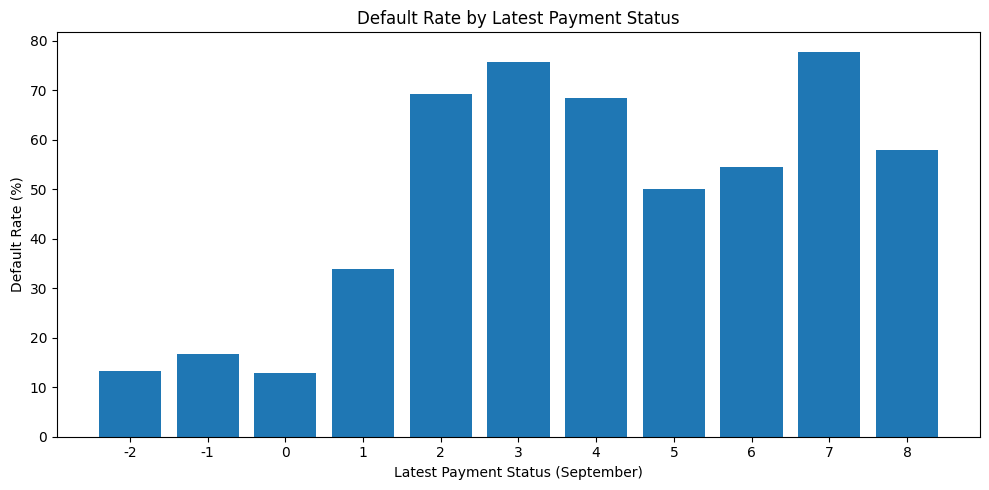

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    default_by_latest_status["pay_status_sep"].astype(str),
    default_by_latest_status["default_rate_percent"]
)

plt.xlabel("Latest Payment Status (September)")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Latest Payment Status")

plt.tight_layout()
plt.show()

The observed default rate rises substantially from 12.81% for payment status 0 to 33.95% for status 1 and 69.14% for status 2. Higher statuses also show high default rates, but these groups contain relatively few customers and should therefore be interpreted cautiously.

**Risk Score**

In [ ]:
# Calculate a risk score based on payment-delay history

df["risk_score"] = (
    df["pay_status_sep"].clip(lower=0)
    + df["pay_status_aug"].clip(lower=0)
    + df["pay_status_jul"].clip(lower=0)
    + df["pay_status_jun"].clip(lower=0)
    + df["pay_status_may"].clip(lower=0)
    + df["pay_status_apr"].clip(lower=0)
)

print(df[[
    "customer_id",
    "pay_status_sep",
    "pay_status_aug",
    "pay_status_jul",
    "pay_status_jun",
    "pay_status_may",
    "pay_status_apr",
    "risk_score"
]].head())

   customer_id  pay_status_sep  pay_status_aug  pay_status_jul  \
0            1               2               2              -1   
1            2              -1               2               0   
2            3               0               0               0   
3            4               0               0               0   
4            5              -1               0              -1   

   pay_status_jun  pay_status_may  pay_status_apr  risk_score  
0              -1              -2              -2           4  
1               0               0               2           4  
2               0               0               0           0  
3               0               0               0           0  
4               0               0               0           0  


In [ ]:
# Select the 20 customers with the highest risk scores

top_20_risky = (
    df.sort_values("risk_score", ascending=False)
      .head(20)
)

print(top_20_risky[[
    "customer_id",
    "pay_status_sep",
    "pay_status_aug",
    "pay_status_jul",
    "pay_status_jun",
    "pay_status_may",
    "pay_status_apr",
    "risk_score"
]])

       customer_id  pay_status_sep  pay_status_aug  pay_status_jul  \
8654          8655               2               2               8   
2916          2917               8               7               6   
831            832               8               7               6   
25869        25870               8               7               6   
8997          8998               8               7               6   
13261        13262               8               7               6   
11554        11555               8               7               6   
4336          4337               8               7               6   
981            982               8               7               6   
649            650               8               7               6   
4387          4388               8               7               6   
2362          2363               8               7               6   
18867        18868               8               7               6   
9979          9980  

In [ ]:
print("Number of customers with risk score 33:",
      (df["risk_score"] == 33).sum())

Number of customers with risk score 33: 19


### Risk Ranking

To identify the 20 riskiest customers, a simple payment-delay risk score was calculated using the six monthly payment-status fields from April to September.

Only positive payment-status values (1–8) contribute to the score because these values represent documented payment delays in the UCI data documentation. Values below 0 and 0 were not assigned positive risk points. The `default_next_month` target was not used in the risk score to avoid using the outcome when selecting customers.

The risk score is calculated as the sum of the six monthly payment-status values after treating values below 0 as zero. Customers with higher scores have a greater amount of documented payment-delay history across the six months.

The 20 customers with the highest risk scores were selected as the flagged customers for the LLM analysis. The selected group contains one customer with a risk score of 36 and nineteen customers tied at a score of 33.

**Defaulters in Top-20%**

In [ ]:
top_20_percent_count = int(len(df) * 0.20)

top_20_percent_risky = (
    df.sort_values(
        ["risk_score", "customer_id"],
        ascending=[False, True]
    )
    .head(top_20_percent_count)
)

total_defaulters = df["default_next_month"].sum()
defaulters_in_top_20 = top_20_percent_risky["default_next_month"].sum()

capture_rate = defaulters_in_top_20 / total_defaulters * 100

print("Top 20% customers:", top_20_percent_count)
print("Total defaulters:", total_defaulters)
print("Defaulters in top 20%:", defaulters_in_top_20)
print("Share of all defaulters captured:", f"{capture_rate:.2f}%")

Top 20% customers: 6000
Total defaulters: 6636
Defaulters in top 20%: 3099
Share of all defaulters captured: 46.70%


### Top 20% Risk Capture

The risk score was evaluated by selecting the top 20% of customers based on risk score. Since the dataset contains 30,000 customers, the top 20% contains 6,000 customers.

Because multiple customers can have the same risk score, `customer_id` in ascending order was used as a deterministic tie-breaker so that exactly 6,000 customers were selected.

There were 6,636 defaulters in the full dataset, of which 3,099 were included in the top 20% riskiest customers.

Therefore, the top 20% risk group captured **46.70% of all defaulters**.

This means that the simple payment-delay risk score concentrated nearly half of all observed defaulters within the highest-risk 20% of customers. This is an observed result from this dataset and should not be interpreted as a guarantee of future performance.

# Part C — AI

The purpose of Part C is to identify 20 high-risk customers and use an LLM to generate a short explanation for a collections agent. Each generated note will then be checked against the original customer data to identify unsupported or incorrect facts.

In [ ]:
llm_fields = [
    "customer_id",
    "credit_limit",
    "age",
    "pay_status_sep",
    "pay_status_aug",
    "pay_status_jul",
    "pay_status_jun",
    "pay_status_may",
    "pay_status_apr",
    "bill_amt_sep",
    "bill_amt_aug",
    "bill_amt_jul",
    "bill_amt_jun",
    "bill_amt_may",
    "bill_amt_apr",
    "pay_amt_sep",
    "pay_amt_aug",
    "pay_amt_jul",
    "pay_amt_jun",
    "pay_amt_may",
    "pay_amt_apr"
]

print("Number of fields sent to the LLM:", len(llm_fields))

Number of fields sent to the LLM: 21


In [ ]:
top_20_for_llm = top_20_risky[llm_fields].copy()

print("Number of customers:", len(top_20_for_llm))
print("Number of fields:", len(top_20_for_llm.columns))

top_20_for_llm.head()

Number of customers: 20
Number of fields: 21


,customer_id,credit_limit,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amt_sep,...,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
8654,8655,30000,47,2,2,8,8,8,8,2400,...,2400,2400,2400,2400,0,0,0,0,0,0
2916,2917,20000,26,8,7,6,5,4,3,43340,...,35381,31539,27409,23567,0,0,0,0,0,300
831,832,20000,24,8,7,6,5,4,3,24310,...,23353,22719,21796,21162,0,0,0,0,0,0
25869,25870,510000,40,8,7,6,5,4,3,477094,...,461402,452405,443657,437305,0,0,0,0,0,14000
8997,8998,80000,31,8,7,6,5,4,3,126786,...,121216,97622,88878,80518,0,0,0,0,0,0


In [ ]:
llm_prompt = """
You are a collections-support assistant.

Using only the customer information provided below, write a concise two-line note
for a collections agent explaining why this customer was flagged as high risk.

Rules:
- Use only facts that are explicitly present in the provided customer data.
- Focus on payment-status history, bill amounts, and payment amounts.
- Payment-status values 1–8 represent documented payment delays.
- Do not assign meanings to payment-status values -2 or 0 beyond what is explicitly provided.
- Monetary amounts in this dataset are in NT dollars.
- When mentioning a monetary amount, use the format NT$ followed by the amount.
- Do not convert the amounts to another currency.
- Do not invent or assume income, employment, financial hardship, personal circumstances,
  or any other information not provided.
- Do not state that the customer will definitely default.
- Do not describe a payment as "insufficient", "unaffordable", or similar unless
  the statement is directly supported by the provided data.
- Do not describe the customer as having financial difficulty, overextension,
  or other personal/financial circumstances unless directly supported by the data.
- Keep the note factual and concise.
- Write exactly two lines.

Customer information:
{customer_data}
"""

print(llm_prompt)


You are a collections-support assistant.

Using only the customer information provided below, write a concise two-line note
for a collections agent explaining why this customer was flagged as high risk.

Rules:
- Use only facts that are explicitly present in the provided customer data.
- Focus on payment-status history, bill amounts, and payment amounts.
- Payment-status values 1–8 represent documented payment delays.
- Do not assign meanings to payment-status values -2 or 0 beyond what is explicitly provided.
- Monetary amounts in this dataset are in NT dollars.
- When mentioning a monetary amount, use the format NT$ followed by the amount.
- Do not convert the amounts to another currency.
- Do not invent or assume income, employment, financial hardship, personal circumstances,
  or any other information not provided.
- Do not state that the customer will definitely default.
- Do not describe a payment as "insufficient", "unaffordable", or similar unless
  the statement is directly s

In [ ]:
first_customer = top_20_for_llm.iloc[0]

customer_data = first_customer.to_dict()

print(customer_data)

{'customer_id': 8655, 'credit_limit': 30000, 'age': 47, 'pay_status_sep': 2, 'pay_status_aug': 2, 'pay_status_jul': 8, 'pay_status_jun': 8, 'pay_status_may': 8, 'pay_status_apr': 8, 'bill_amt_sep': 2400, 'bill_amt_aug': 2400, 'bill_amt_jul': 2400, 'bill_amt_jun': 2400, 'bill_amt_may': 2400, 'bill_amt_apr': 2400, 'pay_amt_sep': 0, 'pay_amt_aug': 0, 'pay_amt_jul': 0, 'pay_amt_jun': 0, 'pay_amt_may': 0, 'pay_amt_apr': 0}


In [ ]:
customer_data_text = "\n".join(
    f"{key}: {value}"
    for key, value in customer_data.items()
)

customer_prompt = llm_prompt.format(
    customer_data=customer_data_text
)

print(customer_prompt)


You are a collections-support assistant.

Using only the customer information provided below, write a concise two-line note
for a collections agent explaining why this customer was flagged as high risk.

Rules:
- Use only facts that are explicitly present in the provided customer data.
- Focus on payment-status history, bill amounts, and payment amounts.
- Payment-status values 1–8 represent documented payment delays.
- Do not assign meanings to payment-status values -2 or 0 beyond what is explicitly provided.
- Monetary amounts in this dataset are in NT dollars.
- When mentioning a monetary amount, use the format NT$ followed by the amount.
- Do not convert the amounts to another currency.
- Do not invent or assume income, employment, financial hardship, personal circumstances,
  or any other information not provided.
- Do not state that the customer will definitely default.
- Do not describe a payment as "insufficient", "unaffordable", or similar unless
  the statement is directly s

In [ ]:
!pip install -q google-genai

In [ ]:
import google.genai

print("google-genai is installed successfully")

google-genai is installed successfully


In [ ]:
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [ ]:
from google import genai

client = genai.Client(api_key=api_key)

print("Gemini client created successfully")

Gemini client created successfully


In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

groq_api_key = userdata.get("GROQ_API_KEY")

print("Groq API key loaded:", groq_api_key is not None)

Groq API key loaded: True


In [ ]:
from groq import Groq

groq_client = Groq(api_key=groq_api_key)

print("Groq client created successfully")

Groq client created successfully


In [ ]:
response = groq_client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": customer_prompt
        }
    ],
    temperature=0
)

print(response.choices[0].message.content)

Customer has documented payment delays in all six months (pay_status 2 or 8) and has not made any payments (pay_amt 0).  
Each month’s bill was NT$2400, totaling NT$14,400 over the period, with no payments recorded.


In [ ]:
import time

generated_notes = []

for _, customer in top_20_for_llm.iterrows():

    customer_data_text = "\n".join(
        f"{key}: {value}"
        for key, value in customer.to_dict().items()
    )

    customer_prompt = llm_prompt.format(
        customer_data=customer_data_text
    )

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": customer_prompt
            }
        ],
        temperature=0
    )

    generated_notes.append({
        "customer_id": customer["customer_id"],
        "note": response.choices[0].message.content
    })

    time.sleep(1)

print("Generated notes:", len(generated_notes))

Generated notes: 20


**Generated notes**

In [ ]:
for item in generated_notes:
    print("Customer ID:", item["customer_id"])
    print(item["note"])
    print("-" * 80)

Customer ID: 8655
Customer 8655 has recorded payment delays (status 2 in Sep/Aug, status 8 in Apr–Jul) across six consecutive months.  
Despite monthly bills of NT$2400, the customer has paid NT$0 each month, indicating a high risk of default.
--------------------------------------------------------------------------------
Customer ID: 2917
Customer has escalating payment delays (pay_status Apr 3 to Sep 8) and has not paid any bill amounts (Sep NT$43340, Aug NT$42619, Jul NT$35381, Jun NT$31539, May NT$27409) beyond a single NT$300 payment in Apr.  
Bill amounts consistently exceed the credit limit of NT$20000, indicating a high risk of non‑payment.
--------------------------------------------------------------------------------
Customer ID: 832
Customer has documented payment delays each month from Apr (status 3) to Sep (status 8) with no payments recorded (pay_amt = 0).  
Bill amounts rose from NT$21162 in Apr to NT$24310 in Sep, indicating a growing unpaid balance.
-----------------

**Compares generated notes with Source data**

In [ ]:
for item in generated_notes:
    customer_id = item["customer_id"]

    customer = top_20_for_llm[
        top_20_for_llm["customer_id"] == customer_id
    ].iloc[0]

    print("=" * 100)
    print("CUSTOMER ID:", customer_id)
    print("\nAI-GENERATED NOTE:")
    print(item["note"])

    print("\nACTUAL DATA:")
    print(customer.to_dict())

CUSTOMER ID: 8655

AI-GENERATED NOTE:
Customer 8655 has recorded payment delays (status 2 in Sep/Aug, status 8 in Apr–Jul) across six consecutive months.  
Despite monthly bills of NT$2400, the customer has paid NT$0 each month, indicating a high risk of default.

ACTUAL DATA:
{'customer_id': 8655, 'credit_limit': 30000, 'age': 47, 'pay_status_sep': 2, 'pay_status_aug': 2, 'pay_status_jul': 8, 'pay_status_jun': 8, 'pay_status_may': 8, 'pay_status_apr': 8, 'bill_amt_sep': 2400, 'bill_amt_aug': 2400, 'bill_amt_jul': 2400, 'bill_amt_jun': 2400, 'bill_amt_may': 2400, 'bill_amt_apr': 2400, 'pay_amt_sep': 0, 'pay_amt_aug': 0, 'pay_amt_jul': 0, 'pay_amt_jun': 0, 'pay_amt_may': 0, 'pay_amt_apr': 0}
CUSTOMER ID: 2917

AI-GENERATED NOTE:
Customer has escalating payment delays (pay_status Apr 3 to Sep 8) and has not paid any bill amounts (Sep NT$43340, Aug NT$42619, Jul NT$35381, Jun NT$31539, May NT$27409) beyond a single NT$300 payment in Apr.  
Bill amounts consistently exceed the credit limit

In [ ]:
# Part C — Final Factuality Review

final_fact_check_results = [
    {
        "customer_id": 8655,
        "result": "OK",
        "reason": "Payment delays, NT$2,400 monthly bills, and zero payments are supported by the data."
    },
    {
        "customer_id": 2917,
        "result": "OK",
        "reason": "Payment-status trend, NT$300 April payment, zero payments from May-Sep, and bill amounts are supported by the data."
    },
    {
        "customer_id": 832,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 25870,
        "result": "OK",
        "reason": "Payment-status trend, NT$14,000 April payment, zero payments from May-Sep, and bill amounts are supported by the data."
    },
    {
        "customer_id": 8998,
        "result": "OK",
        "reason": "Payment-status trend, bill amounts, and zero payments are supported by the data."
    },
    {
        "customer_id": 13262,
        "result": "OK",
        "reason": "Bill amounts, credit limit, zero payments, and payment-status trend are supported by the data."
    },
    {
        "customer_id": 11555,
        "result": "Issue",
        "reason": "The note first states that there was a NT$15 payment in April, but later says payment amounts remained zero. April payment was NT$15."
    },
    {
        "customer_id": 4337,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 982,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 650,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 4388,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 2363,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, bill amounts, and credit limit comparison are supported by the data."
    },
    {
        "customer_id": 18868,
        "result": "OK",
        "reason": "Payment-status trend, NT$6,000 May payment, five zero-payment months, and bill amounts are supported by the data."
    },
    {
        "customer_id": 9980,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 13636,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 4445,
        "result": "OK",
        "reason": "Payment-status trend, five zero-payment months, NT$1,170 July payment, bill amounts, and credit-limit comparison are supported by the data."
    },
    {
        "customer_id": 6754,
        "result": "OK",
        "reason": "Payment-status trend, NT$780 July payment, zero payments in the other months, bill amounts, and credit-limit comparison are supported by the data."
    },
    {
        "customer_id": 23040,
        "result": "OK",
        "reason": "Payment-status trend, zero payments, and bill amounts are supported by the data."
    },
    {
        "customer_id": 13713,
        "result": "Issue",
        "reason": "The note says there were no payments from April to August but also states that NT$70 was paid in July. July payment was NT$70."
    },
    {
        "customer_id": 750,
        "result": "Issue",
        "reason": "The note says there were zero payments in April but also states that NT$3,000 was paid in April. April payment was NT$3,000."
    }
]

final_fact_check_df = pd.DataFrame(final_fact_check_results)

print("Final Part C Factuality Review")
print("=" * 60)
print("Total notes reviewed:", len(final_fact_check_df))
print("Notes with identified issues:", (final_fact_check_df["result"] == "Issue").sum())
print("Notes without identified issues:", (final_fact_check_df["result"] == "OK").sum())
print(
    "Issue rate:",
    f"{(final_fact_check_df['result'] == 'Issue').mean() * 100:.1f}%"
)

final_fact_check_df

Final Part C Factuality Review
Total notes reviewed: 20
Notes with identified issues: 3
Notes without identified issues: 17
Issue rate: 15.0%


,customer_id,result,reason
0,8655,OK,"Payment delays, NT$2,400 monthly bills, and ze..."
1,2917,OK,"Payment-status trend, NT$300 April payment, ze..."
2,832,OK,"Payment-status trend, zero payments, and bill ..."
3,25870,OK,"Payment-status trend, NT$14,000 April payment,..."
4,8998,OK,"Payment-status trend, bill amounts, and zero p..."
5,13262,OK,"Bill amounts, credit limit, zero payments, and..."
6,11555,Issue,The note first states that there was a NT$15 p...
7,4337,OK,"Payment-status trend, zero payments, and bill ..."
8,982,OK,"Payment-status trend, zero payments, and bill ..."
9,650,OK,"Payment-status trend, zero payments, and bill ..."


In [ ]:
print("Final Part C Factuality Review")
print("=" * 50)

total = len(final_fact_check_df)
issues = (final_fact_check_df["result"] == "Issue").sum()
ok = (final_fact_check_df["result"] == "OK").sum()

print("Total notes reviewed:", total)
print("Notes with identified issues:", issues)
print("Notes without identified issues:", ok)
print("Issue rate:", f"{issues / total * 100:.1f}%")

print("\nIssues identified:")
print("=" * 50)

issues_only = final_fact_check_df[
    final_fact_check_df["result"] == "Issue"
]

for _, row in issues_only.iterrows():
    print(f"\nCustomer ID: {row['customer_id']}")
    print(f"Reason: {row['reason']}")

Final Part C Factuality Review
Total notes reviewed: 20
Notes with identified issues: 3
Notes without identified issues: 17
Issue rate: 15.0%

Issues identified:

Customer ID: 11555
Reason: The note first states that there was a NT$15 payment in April, but later says payment amounts remained zero. April payment was NT$15.

Customer ID: 13713
Reason: The note says there were no payments from April to August but also states that NT$70 was paid in July. July payment was NT$70.

Customer ID: 750
Reason: The note says there were zero payments in April but also states that NT$3,000 was paid in April. April payment was NT$3,000.


## 3. Factuality Check Summary

All 20 LLM-generated notes were reviewed against the original customer data provided to the LLM.

A note was marked as having an issue when it contained a factual statement that contradicted the supplied customer data or a specific claim that could not be supported by the supplied fields. Reasonable summaries directly derived from the numerical data were not treated as errors.

### Results

- **Total notes reviewed:** 20
- **Notes with identified issues:** 3
- **Notes without identified issues:** 17
- **Issue rate:** 15.0%

### Examples of Identified Issues

- **Customer 11555:** The note correctly mentions a NT\$15 payment in April but later states that payment amounts remained zero. The April payment amount was NT\$15.

- **Customer 13713:** The note states that there were no payments from April to August but also states that NT\$70 was paid in July. The July payment amount was NT\$70.

- **Customer 750:** The note states that there were zero payments in April but also states that NT\$3,000 was paid in April. The April payment amount was NT\$3,000.


### Conclusion

The LLM generated useful summaries of the customers' payment history, but factual checking was still necessary. Three of the 20 notes contained clear inconsistencies with the source data. This demonstrates that LLM-generated collection notes should be reviewed against the underlying customer data before being used by a collections team.

Part C - Summary

The 20 highest-risk customers were selected using a payment-delay risk score based on the six monthly payment-status fields, without using the `default_next_month` target.

An LLM (`openai/gpt-oss-20b` through Groq) was then given only the selected customers' relevant fields and asked to generate concise two-line collection notes.

All 20 generated notes were manually checked against the original customer data provided to the LLM. **17 of 20 notes (85%) had no identified factual inconsistency, while 3 of 20 notes (15%) contained clear factual inconsistencies.**

The results show that an LLM can produce useful summaries of structured customer payment information, but every generated note should still be checked against the underlying data before being used for collection decisions.

# Recommendation

## How should the collections team use this list next month?

The collections team can use the high-risk list as a prioritization tool for early outreach. Customers with higher payment-delay risk scores and recent documented payment delays can be reviewed first, so that collection agents can focus their attention on customers showing stronger signals of payment difficulty.

The list should support human review rather than automatically determining collection actions. Before contacting a customer, agents should verify the underlying payment history and other available business information.

## Which fields should never be used for decisions?

Fields such as **sex, education, and marriage** should not be used to decide which customers receive collection priority. They are demographic or personal characteristics rather than direct measures of payment behavior.

Collection prioritization should instead rely on relevant payment-behavior information, such as documented payment-status history and payment/bill amounts, while avoiding assumptions about a customer's personal circumstances.

# Optional Extra — Analytics

The optional Analytics track compares the simple points-based risk score with a logistic regression model.

Both methods are evaluated using the share of all observed defaulters captured within the top 20% of customers ranked by risk.

In [ ]:
# Import pandas for working with the dataset
import pandas as pd

# Split the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Scale numerical columns and encode categorical columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Apply different preprocessing to different columns
from sklearn.compose import ColumnTransformer

# Combine preprocessing and the machine-learning model
from sklearn.pipeline import Pipeline

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

**Define Model Features and Target**

In [ ]:
# Numerical features:
# These are values where treating them as numbers makes sense.
numeric_features = [
    "credit_limit",
    "age",
    "bill_amt_sep",
    "bill_amt_aug",
    "bill_amt_jul",
    "bill_amt_jun",
    "bill_amt_may",
    "bill_amt_apr",
    "pay_amt_sep",
    "pay_amt_aug",
    "pay_amt_jul",
    "pay_amt_jun",
    "pay_amt_may",
    "pay_amt_apr"
]

# Payment-status features:
# We treat these as categories because the codes are not ordinary measurements.
categorical_features = [
    "pay_status_sep",
    "pay_status_aug",
    "pay_status_jul",
    "pay_status_jun",
    "pay_status_may",
    "pay_status_apr"
]

# Combine both groups to create the model's input features.
feature_columns = numeric_features + categorical_features

# X contains the information given to the model.
X = df[feature_columns]

# y contains the actual outcome we want the model to predict.
y = df["default_next_month"]

# Check the number of rows and columns being used.
print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 20)
Target: (30000,)


**Train-Test Split**

In [ ]:
# Split the dataset into training data and testing data.
# 80% will be used to train the model.
# 20% will be kept aside to test the model.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,       # Use 20% of the data for testing
    random_state=42,      # Keeps the split the same every time we run it
    stratify=y            # Keeps the same default/non-default proportion in both sets
)

# Check the sizes of the training and testing data.
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 20)
Testing data: (6000, 20)


In [ ]:
# For numerical columns:
# StandardScaler changes the values to a similar scale.
numeric_transformer = StandardScaler()

# For payment-status columns:
# OneHotEncoder converts each status code into separate categories.
# handle_unknown="ignore" prevents errors if a new category appears in the test data.
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Apply the correct preprocessing to each group of columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [ ]:
# Create a pipeline that:
# 1. Preprocesses the numerical and categorical features
# 2. Trains the Logistic Regression model

logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression model is ready.")

Logistic Regression model is ready.


In [ ]:
# Train the logistic regression model using the training data.
# The pipeline will automatically:
# 1. Scale the numerical columns
# 2. Encode the payment-status columns
# 3. Train the logistic regression model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Predict the probability of default for each customer in the test data.
# [:, 1] selects the probability of class 1, where 1 means default.

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Check the first 10 predicted probabilities.
print(test_probabilities[:10])

[0.15059673 0.16938368 0.12977138 0.10293154 0.06409812 0.23142088
 0.10743944 0.07671267 0.09466442 0.11615889]


**Rank Customers by Predicted Risk**

In [ ]:
# Create a copy of the test data so we can add prediction results to it.
test_results = X_test.copy()

# Add the actual default outcome for each customer.
test_results["actual_default"] = y_test.values

# Add the probability of default predicted by Logistic Regression.
test_results["predicted_probability"] = test_probabilities

# Sort customers from highest predicted risk to lowest predicted risk.
test_results = test_results.sort_values(
    "predicted_probability",
    ascending=False
)

# Display the 10 customers with the highest predicted risk.
print(test_results[["predicted_probability", "actual_default"]].head(10))

       predicted_probability  actual_default
8046                0.922894               0
20756               0.894281               1
4432                0.888878               0
29726               0.885565               1
26880               0.884324               0
10337               0.875474               1
5592                0.875008               0
21380               0.873250               1
29976               0.872711               1
29151               0.871853               1


**Logistic Regression — Top 20% Capture**

In [ ]:
# Calculate how many customers are in the top 20% of the test data.
top_20_count = int(len(test_results) * 0.20)

# Select the 20% of customers with the highest predicted risk.
top_20_logistic = test_results.head(top_20_count)

# Count how many actual defaulters are in this top 20%.
logistic_defaulters_captured = top_20_logistic["actual_default"].sum()

# Count the total number of actual defaulters in the test data.
total_test_defaulters = test_results["actual_default"].sum()

# Calculate the percentage of all test defaulters captured in the top 20%.
logistic_capture_rate = (
    logistic_defaulters_captured / total_test_defaulters
) * 100

print("Top 20% customer count:", top_20_count)
print("Total test defaulters:", total_test_defaulters)
print("Defaulters captured in top 20%:", logistic_defaulters_captured)
print("Logistic Regression top-20% capture:", round(logistic_capture_rate, 2), "%")

Top 20% customer count: 1200
Total test defaulters: 1327
Defaulters captured in top 20%: 651
Logistic Regression top-20% capture: 49.06 %


**Points Score — Same Test Set**

In [ ]:
# Add the existing points-based risk score to the test results.
test_results["risk_score"] = df.loc[
    test_results.index, "risk_score"
]

# Sort the test customers by the points-based risk score.
points_test_results = test_results.sort_values(
    "risk_score",
    ascending=False
)

# Select the same top 20% of test customers.
top_20_points = points_test_results.head(top_20_count)

# Count the actual defaulters captured by the points score.
points_defaulters_captured = top_20_points["actual_default"].sum()

# Calculate the points-score capture rate.
points_capture_rate = (
    points_defaulters_captured / total_test_defaulters
) * 100

print("Defaulters captured by points score:", points_defaulters_captured)
print("Points-score top-20% capture:",
      round(points_capture_rate, 2), "%")

Defaulters captured by points score: 595
Points-score top-20% capture: 44.84 %


## 11. Model Comparison

The logistic regression model was evaluated on the 20% held-out test set.

The test set contained **6,000 customers**, including **1,327 actual defaulters**. The top 20% contained **1,200 customers**.

Logistic regression captured **651 defaulters**, giving a **49.06% top-20% capture rate**.

For a fair comparison, the existing points-based risk score was also evaluated on the **same 6,000 test customers** and the same top 20% group size. It captured **595 defaulters**, giving a **44.84% top-20% capture rate**.

Therefore, logistic regression performed **4.22 percentage points higher** than the points-based score on this test set.

The points-based score remains simpler and easier to explain, while logistic regression provides stronger top-20% capture on this particular test set.